In [8]:
import sys
!{sys.executable} -m pip install matplotlib seaborn statsmodels scikit-learn openpyxl

# IMPORTAR LIBRERÍAS

In [9]:
# Librerías utilizadas


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

# CARGAR LOS DATOS 

Cargamos el Excel ya limpio. Cada fila es un préstamo/cliente. Las variables categóricas (estudios, tipo de jornada, estado civil) ya vienen codificadas como **variables dummy** (True/False).

In [10]:

base_path = Path.cwd()

prestamos = pd.read_excel(base_path / "datos" / "datos_limpio_automovil.xlsx")
prestamos.head(5)

,Unnamed: 0,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,...,Estudios_Escolar,Estudios_Grado Universitario,Estudios_Máster,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,0,O77MPJ,26,19153,6973,706,9,1,19.05,36,...,False,True,False,False,False,True,False,False,False,True
1,8,IYOL1S,29,39531,40000,826,0,1,9.74,24,...,False,False,False,False,False,True,False,True,False,False
2,9,FRMZVN,29,40348,16448,740,9,1,14.73,24,...,False,False,True,False,False,True,False,False,False,True
3,26,YKHXVY,38,41732,42040,661,173,2,13.24,48,...,False,True,False,False,False,False,True,True,False,False
4,32,NHDJTK,35,35085,16406,759,181,1,9.74,36,...,True,False,False,False,False,True,False,True,False,False


# ANALISIS DESCRIPTIVO

### Resumen estadístico general

In [11]:
prestamos.describe()

,Unnamed: 0,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Posesion_Hipoteca,Personas_Cargo,Fiador,Impago,Prima
count,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000,76924.000000
mean,255090.200783,39.654789,41536.575555,44730.183922,692.082757,212.577557,2.001885,10.652821,37.260309,0.319806,0.350710,0.448963,0.301258,0.115517,383.694225
std,147256.705977,10.088582,16014.092493,46407.624924,87.772342,150.346325,1.002854,3.813562,14.154771,0.181095,0.477195,0.497392,0.458808,0.319646,267.385642
min,0.000000,19.000000,16000.000000,3000.000000,398.000000,0.000000,1.000000,2.010000,12.000000,0.100000,0.000000,0.000000,0.000000,0.000000,10.000000
25%,128111.750000,33.000000,30503.750000,14940.750000,635.000000,70.000000,1.000000,7.930000,24.000000,0.140000,0.000000,0.000000,0.000000,0.000000,137.130000
50%,255081.500000,40.000000,39159.000000,40000.000000,703.000000,208.000000,2.000000,10.550000,36.000000,0.290000,0.000000,0.000000,0.000000,0.000000,332.670000
75%,382469.500000,46.000000,50100.000000,46480.000000,761.000000,337.000000,3.000000,13.240000,48.000000,0.550000,1.000000,1.000000,1.000000,0.000000,610.615000
max,510700.000000,64.000000,120000.000000,400000.000000,845.000000,622.000000,4.000000,24.440000,60.000000,0.550000,1.000000,1.000000,1.000000,1.000000,800.000000


**Interpretación del `describe()`.**
- El 88,45 % de los préstamos se han pagado (`Impago = 0`) y el 11,55 % han resultado impagados (`Impago = 1`).
- Las variables están en **escalas muy diferentes**: `Ingresos` y `Monto_Inicial` en decenas de miles, `Scoring_Crediticio` en cientos, `Ratio_Deuda_Ingresos` entre 0,10 y 0,55, y las dummies entre 0 y 1. Por eso conviene **estandarizar** antes de ajustar el modelo, igual que en el ejemplo.
- La media de `Impago` (0,1155) coincide con la tasa de impago del 11,55 %.
-- `Unnamed: 0` es solo el índice antiguo del fichero e `ID` es un identificador: no aportan información, por eso las excluimos de `X` en el paso de selección de variables.

### Calidad de los datos: tipos, nulos y duplicados

In [12]:
print("Dimensiones:", prestamos.shape)
print("Valores nulos totales:", prestamos.isna().sum().sum())
print("IDs duplicados:", prestamos["ID"].duplicated().sum())
print()
print(prestamos.dtypes.value_counts())

Dimensiones: (76924, 27)
Valores nulos totales: 0
IDs duplicados: 0

int64      12
bool       11
float64     3
str         1
Name: count, dtype: int64


 76.924 préstamos y 27 columnas, **sin valores nulos ni IDs duplicados**: el dataset ya está limpio. Hay variables numéricas (enteras y decimales), dummies booleanas (True/False) y el `ID` como texto.

### Distribución de la variable respuesta `Impago`

`Impago` es la variable que queremos predecir (1 = no paga, 0 = paga). Antes de ajustar nada necesitamos saber **cuántos casos hay de cada clase**, por cuatro motivos:

1. **Fija la referencia mínima que el modelo debe superar.** Si una clase es muy mayoritaria, un "modelo" que prediga siempre esa clase ya acierta ese porcentaje sin aprender nada. Cualquier modelo útil tiene que superar ese acierto.
2. **Detecta el desbalanceo de clases.** Si una clase es mucho menos frecuente, la *accuracy* deja de ser una buena métrica y hay que fijarse en recall, precisión, curva ROC/AUC y en el umbral de clasificación.
3. **Justifica la partición estratificada** (`stratify=y`): queremos que train y test tengan la misma proporción de impagos.
4. **Es la tasa de impago base de la cartera** (la PD media). Para el reto es un dato de negocio en sí mismo: de cada 100 préstamos, cuántos acaban impagados. Sirve además para comprobar al final que las probabilidades del modelo son coherentes con ella (calibración).

In [13]:
print("Número de observaciones por clase") 
print(prestamos['Impago'].value_counts())
print("")

print("Porcentaje de observaciones por clase")
print(100 * prestamos['Impago'].value_counts(normalize=True))

Número de observaciones por clase
Impago
0    68038
1     8886
Name: count, dtype: int64

Porcentaje de observaciones por clase
Impago
0    88.448339
1    11.551661
Name: proportion, dtype: float64


### Matriz de correlaciones
Mide la relación lineal entre variables (−1 a 1). Nos interesa: (a) la correlación de cada variable con `Impago` y (b) correlaciones altas entre predictores, que anticipan multicolinealidad.

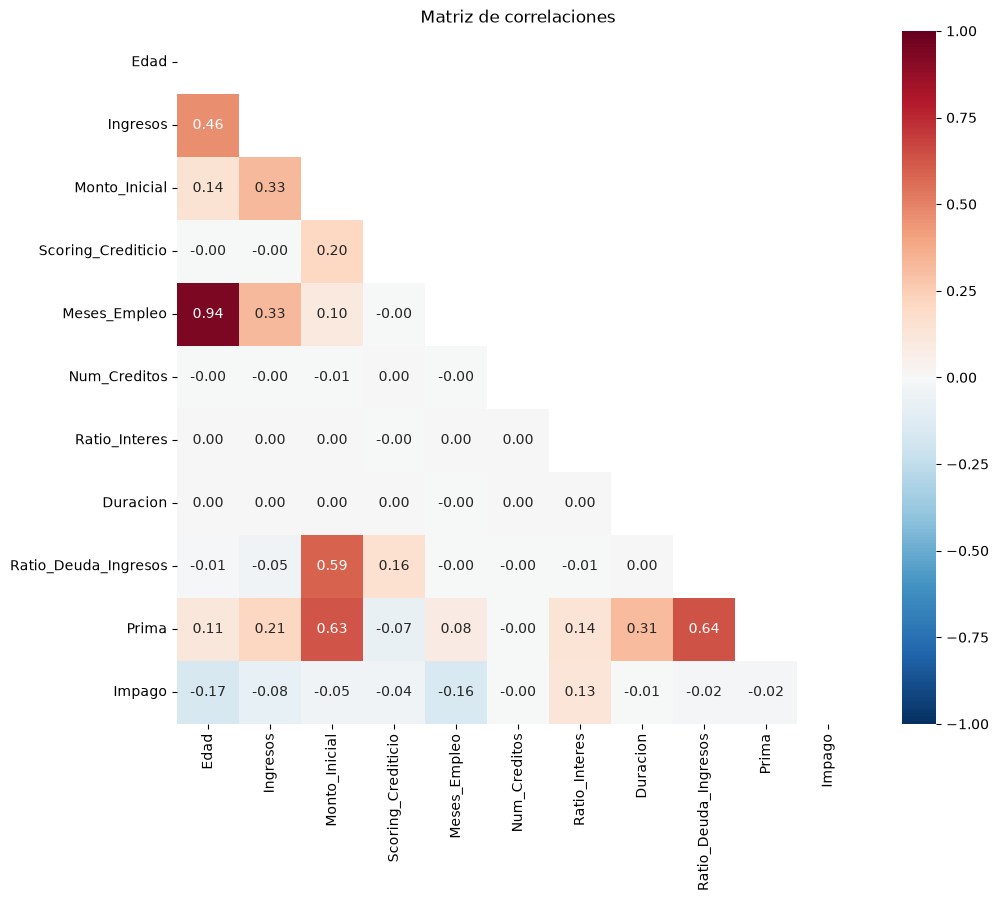

Correlación de cada variable con Impago:
Edad                   -0.166
Meses_Empleo           -0.161
Ingresos               -0.083
Monto_Inicial          -0.047
Scoring_Crediticio     -0.040
Ratio_Deuda_Ingresos   -0.023
Prima                  -0.018
Duracion               -0.006
Num_Creditos           -0.001
Ratio_Interes           0.128
Name: Impago, dtype: float64


In [15]:
vars_num = ["Edad", "Ingresos", "Monto_Inicial", "Scoring_Crediticio", "Meses_Empleo",
            "Num_Creditos", "Ratio_Interes", "Duracion", "Ratio_Deuda_Ingresos", "Prima"]

corr = prestamos[vars_num + ["Impago"]].corr()

plt.figure(figsize=(11, 9))
mascara = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlaciones")
plt.show()

print("Correlación de cada variable con Impago:")
print(corr["Impago"].drop("Impago").sort_values().round(3))

**Interpretación.**
- **Correlación con `Impago`**: las más altas son `Edad` (−0,17), `Meses_Empleo` (−0,16) y `Ratio_Interes` (+0,13), seguidas de `Ingresos` (−0,08). Son correlaciones **bajas en valor absoluto**, algo normal con una variable binaria y desbalanceada. Anticipan un pseudo R² modesto.
- **`Edad` y `Meses_Empleo` correlación 0,94**: casi miden lo mismo. Esto anticipa un problema de **multicolinealidad** en el modelo.
- **`Edad`–`Ingresos` (0,46)** e **`Ingresos`–`Meses_Empleo` (0,33)**: `Ingresos` está relacionada con la edad y la antigüedad, por lo que es posible que en el modelo pierda importancia, ya que su efecto lo pueden recoger esas variables.
- **`Prima`** está correlacionada con `Monto_Inicial` (0,63), `Ratio_Deuda_Ingresos` (0,64) y `Duracion` (0,31), pero casi nada con `Impago` (−0,02). La prima depende sobre todo del **importe y plazo** del préstamo y **no** es una característica del cliente que prediga el impago, por eso la dejamos fuera del modelo.

# SEPARAR ENTRE X Y Y



**Variables que eliminamos de `X`:**
- `Impago`: es la variable respuesta (`y`).
- `Unnamed: 0` e `ID`: identificadores sin valor predictivo.
- `Prima`: es la prima del seguro, es decir, **algo que se calcula a partir del riesgo** y no una característica del cliente. Usarla para predecir el impago sería *data leakage* (además, el objetivo final del reto es justamente estimar ese coste).
- **Una categoría de referencia por cada grupo de dummies**: `Estudios_Escolar`, `Tipo_Jornada_Laboral_Jornada completa` y `Estado_Civil_Casado`. Si se incluyen todas las dummies de un grupo, suman siempre 1 y son perfectamente colineales con la constante (*trampa de las variables ficticias*). Los coeficientes del resto de dummies se interpretan **en comparación con esa categoría de referencia**.

**Partición:** 80 % entrenamiento y 20 % test, con `random_state = 42` para que sea reproducible. Añadimos `stratify = y` (mejora respecto al ejemplo) para que train y test conserven la misma proporción de impagos (≈11,5 %), algo importante con clases desbalanceadas.

In [ ]:

X = prestamos.drop(columns = ['Impago', 'Unnamed: 0', 'ID', 'Prima',
                              'Estudios_Escolar', 'Tipo_Jornada_Laboral_Jornada completa',
                              'Estado_Civil_Casado'])
y = prestamos['Impago']

X_train, X_test, y_train, y_test = train_test_split(
                                        X, y.values,
                                        train_size   = 0.8,
                                        random_state = 42,
                                        shuffle      = True,
                                        stratify     = y)

# ESCALAR

Con `StandardScaler` transformamos cada variable a media 0 y desviación típica 1: $z = (x - \bar{x})/s$.

- El escalador se ajusta **solo con train** (`fit_transform`) y después se aplica a test con `transform`, para no filtrar información del conjunto de test.
- Consecuencia para la interpretación: cada coeficiente mide el efecto de aumentar la variable **una desviación típica**, lo que permite comparar la importancia relativa de variables que estaban en escalas distintas.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# CREAR MODELO CON SKLEARN

In [ ]:
modelo_log_sklearn = LogisticRegression()
modelo_log_sklearn.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [ ]:
print("Intercept:", modelo_log_sklearn.intercept_)
print("Coeficiente:", list(zip(X.columns, modelo_log_sklearn.coef_.flatten(), )))
print("Accuracy de entrenamiento:", modelo_log_sklearn.score(X_train_scaled, y_train))

Intercept: [-2.22906909]
Coeficiente: [('Edad', np.float64(-0.33689832458325975)), ('Ingresos', np.float64(0.025393810609631647)), ('Monto_Inicial', np.float64(-0.010294413869774333)), ('Scoring_Crediticio', np.float64(-0.12367848641713419)), ('Meses_Empleo', np.float64(-0.27008180424470934)), ('Num_Creditos', np.float64(-0.0004310250911826286)), ('Ratio_Interes', np.float64(0.41181691721177993)), ('Duracion', np.float64(-0.022123520640880866)), ('Ratio_Deuda_Ingresos', np.float64(-0.05736376249000284)), ('Posesion_Hipoteca', np.float64(0.02349229238681531)), ('Personas_Cargo', np.float64(0.0044150696300517085)), ('Fiador', np.float64(-0.0008328970050531917)), ('Estudios_Doctorado', np.float64(-0.038990891038915045)), ('Estudios_Grado Universitario', np.float64(-0.03373939682008496)), ('Estudios_Máster', np.float64(-0.047527837262875974)), ('Tipo_Jornada_Laboral_Autónomo', np.float64(0.023193095457393786)), ('Tipo_Jornada_Laboral_Desempleado', np.float64(-0.0038595713950660454)), ('Tip

**Interpretación.**
- **Intercepto = −2,23.** Para un cliente "medio" (todas las variables estandarizadas = 0, y en las categorías de referencia), la probabilidad estimada de impago es $1/(1+e^{2,23}) \approx 9,7\%$.
- Los coeficientes con mayor valor absoluto son `Ratio_Interes` (+0,41), `Edad` (−0,34), `Meses_Empleo` (−0,27) y `Scoring_Crediticio` (−0,12). El resto son muy cercanos a 0.
- **Accuracy de entrenamiento = 88,44 %**, prácticamente igual a la proporción de la clase mayoritaria (88,45 %). Es una primera señal de que, con el umbral de 0,5, el modelo apenas clasifica nada como impago.

# Predicciones con skealearn

- `.predict_proba()` devuelve, para cada cliente, la probabilidad de cada clase (columna `1` = probabilidad de impago).
- `.predict()` devuelve la clase con mayor probabilidad, es decir, usa un **umbral de 0,5**.

In [ ]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

predicciones = modelo_log_sklearn.predict_proba(X = X_test_scaled)
predicciones = pd.DataFrame(predicciones, columns = modelo_log_sklearn.classes_)
predicciones.head()

,0,1
0,0.927496,0.072504
1,0.781836,0.218164
2,0.923281,0.076719
3,0.862410,0.137590
4,0.847159,0.152841


In [ ]:
predicciones = modelo_log_sklearn.predict(X_test_scaled)
predicciones[:5]

array([0, 0, 0, 0, 0])

In [ ]:
print("Predicciones de impago (1):", (predicciones == 1).sum())
print("Predicciones de no impago (0):", (predicciones == 0).sum())

Predicciones de impago (1): 7
Predicciones de no impago (0): 15378


**Interpretación.** De 15.385 clientes de test, el modelo solo predice **7** como impagos, aunque en realidad hay 1.777. Las probabilidades estimadas casi nunca superan 0,5 (la tasa base es del 11,5 %), así que con ese umbral el modelo prácticamente siempre dice "no impaga". Esto **no significa que el modelo no sirva**: significa que **0,5 no es un umbral adecuado** para un problema tan desbalanceado.

 # STATSMODELS


Ajustamos el mismo modelo (sin regularización, por máxima verosimilitud) para obtener el resumen estadístico.

In [ ]:
X_train_scaled = sm.add_constant(X_train_scaled, prepend=True)
modelo_log_statsm = sm.Logit(endog= y_train, exog = X_train_scaled)
modelo_log_statsm = modelo_log_statsm.fit()
print(modelo_log_statsm.summary())

Optimization terminated successfully.
         Current function value: 0.333513
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                61539
Model:                          Logit   Df Residuals:                    61518
Method:                           MLE   Df Model:                           20
Date:                Mon, 05 Oct 2026   Pseudo R-squ.:                 0.06815
Time:                        16:09:40   Log-Likelihood:                -20524.
converged:                       True   LL-Null:                       -22025.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -2.2298      0.015 



**Lectura del resumen del modelo:**

- **Coeficientes:** cada coeficiente representa el cambio en el *log-odds* de impago cuando la variable aumenta una desviación típica, manteniendo el resto constantes. El **signo** indica la dirección del efecto: positivo aumenta el riesgo de impago y negativo lo reduce.
- **P>|z|:** si es menor que 0,05, la variable es estadísticamente significativa al 5 %.
- **Pseudo R² de McFadden = 0,068:** el modelo reduce la log-verosimilitud un 6,8 % respecto al modelo nulo (sin predictores). Es un valor **bajo**, lo que indica que las variables disponibles explican una parte modesta del impago. En modelos de riesgo de crédito son habituales valores bajos, ya que el impago depende en gran medida de sucesos no observados (pérdida de empleo, enfermedad, gastos imprevistos...).
- **LLR p-value = 0,000:** en conjunto, los predictores mejoran **significativamente** al modelo nulo, por lo que el modelo es globalmente significativo.

**Variables significativas (p < 0,05):**

| Variable | Coef. | Efecto sobre el riesgo de impago |
|---|---|---|
| `Ratio_Interes` | +0,412 | **Aumenta**. Es la variable más influyente (z = 31,8). Los préstamos con un tipo de interés más alto, que suelen concederse a clientes de mayor riesgo, presentan más impagos. |
| `Edad` | −0,336 | **Disminuye**. Los clientes de mayor edad tienen menor probabilidad de impago. |
| `Meses_Empleo` | −0,272 | **Disminuye**. Una mayor antigüedad laboral refleja más estabilidad y se asocia a menos impagos. |
| `Scoring_Crediticio` | −0,124 | **Disminuye**. A mejor scoring, menor riesgo, tal y como cabía esperar. |
| `Ratio_Deuda_Ingresos` | −0,056 | **Disminuye**. Efecto pequeño y contrario a lo esperado, ya que un mayor endeudamiento debería aumentar el riesgo. Puede deberse a que la variable está acotada entre 0,10 y 0,55 en los datos. |
| `Estudios_Máster` | −0,049 | Los clientes con máster presentan un riesgo ligeramente menor que los de estudios escolares (categoría de referencia), aunque está en el límite de la significación (p = 0,046). |

**Variables no significativas:** `Ingresos`, `Monto_Inicial`, `Num_Creditos`, `Duracion`, `Posesion_Hipoteca`, `Personas_Cargo`, `Fiador`, el resto de niveles de estudios, el tipo de jornada laboral y el estado civil. Una vez tenidas en cuenta las variables anteriores, no aportan información adicional para explicar el impago.

**Observación:** los errores estándar de `Edad` (0,056) y `Meses_Empleo` (0,060) son unas cuatro veces mayores que los del resto de variables (≈ 0,013). Esto indica **multicolinealidad** entre ambas, coherente con la correlación de 0,94 observada en el análisis descriptivo. Esta multicolinealidad no afecta a las predicciones, pero sí hace que los efectos individuales de estas dos variables deban interpretarse con cautela.

# ODDS RATIOS Y INTERVALOS DE CONFIANZA


### Intervalos de confianza al 95 % de los coeficientes

In [ ]:
intervalos_ci = modelo_log_statsm.conf_int(alpha=0.05).rename(columns={0: "2.5%", 1: "97.5%"})

intervalos_ci[:4]

,2.5%,97.5%
const,-2.258778,-2.200744
Edad,-0.446010,-0.226614
Ingresos,-0.026072,0.080435
Monto_Inicial,-0.051378,0.027115


**Interpretación.** Si el intervalo **no contiene el 0**, el coeficiente es significativo al 5 %. Por ejemplo, `Edad` tiene un intervalo [−0,446, −0,227], completamente negativo: efecto significativo y reductor del riesgo. En cambio `Ingresos` [−0,026, 0,080] y `Monto_Inicial` [−0,051, 0,027] contienen el 0: no podemos afirmar que tengan efecto.

# Predicciones y métricas de rendimiento

`statsmodels` no tiene `predict_proba()`: su `predict()` ya devuelve directamente la probabilidad de impago. Hay que añadir la constante al conjunto de test.

In [ ]:
X_test_scaled = sm.add_constant(X_test_scaled, has_constant='add')

predicciones = modelo_log_statsm.predict(exog = X_test_scaled)
predicciones[:4]

50731    0.072409
44077    0.218069
33401    0.076888
57216    0.137263
dtype: float64

Clasificamos con el umbral de 0,5 (si la probabilidad ≥ 0,5 → impago).

In [ ]:
clasificacion = np.where(predicciones<0.5, 0, 1)
clasificacion[:4]

array([0, 0, 0, 0])

### Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

acierto = accuracy_score(y_test, clasificacion)
error = 1 - acierto
print("Acierto:", round(acierto*100, 2), "%")
print("Error:", round(error*100, 2), "%")

Acierto: 88.42 %
Error: 11.58 %


**Interpretación.** Acierto = **88,42 %**, que es **ligeramente inferior** al 88,45 % de la clase mayoritaria. Es decir, con umbral 0,5 el modelo **no supera** a la regla trivial "nadie impaga". La accuracy es una métrica engañosa con clases desbalanceadas: hay que mirar precision, recall y la curva ROC.

### Precision, recall y F1-score
- **Precision:** de las veces que el modelo predijo una clase, qué porcentaje acertó.
- **Recall (sensibilidad):** de todos los casos reales de esa clase, qué porcentaje detectó.
- **F1-score:** media armónica de precision y recall.

In [ ]:


from sklearn.metrics import classification_report

print(classification_report(y_test, clasificacion))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     13608
           1       0.14      0.00      0.00      1777

    accuracy                           0.88     15385
   macro avg       0.51      0.50      0.47     15385
weighted avg       0.80      0.88      0.83     15385



**Interpretación.**
- Clase 0 (paga): precision 0,88 y recall 1,00. El modelo "acierta" con los que pagan porque dice que paga prácticamente todo el mundo.
- Clase 1 (impago): **recall = 0,00**. De los 1.777 impagos reales solo detecta 1. Precision 0,14 (de 7 predicciones de impago, 1 correcta).
- **Macro avg F1 = 0,47**: el rendimiento medio entre clases es pobre.

Con umbral 0,5, el modelo **no sirve como clasificador** de impagos.

### Matriz de confusión
Filas = clase real, columnas = clase predicha: `[[VN, FP], [FN, VP]]`.

[[13602     6]
 [ 1776     1]]


<Axes: >

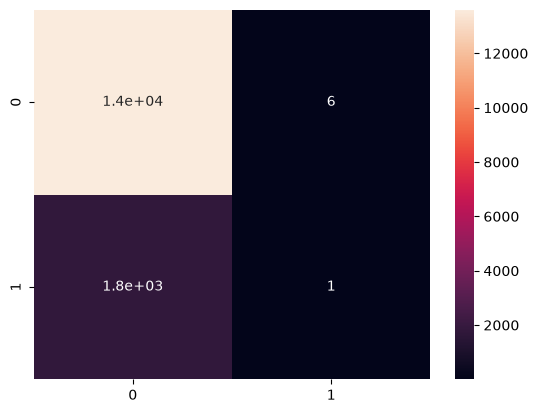

In [ ]:

from sklearn.metrics import confusion_matrix

c_matrix = confusion_matrix(y_test, clasificacion)
print(c_matrix)

sns.heatmap(c_matrix, annot=True)

**Interpretación.** 13.602 verdaderos negativos, 6 falsos positivos, **1.776 falsos negativos** y solo 1 verdadero positivo. Casi todos los impagos se escapan.

### Curva precisión / recall
Muestra cómo cambian precisión y sensibilidad al mover el umbral de probabilidad.

In [ ]:
from sklearn.metrics import precision_recall_curve

# Primero creamos una tabla para ver como varía la precisión y recall en función del valor umbral

prec, rec, thresholds = precision_recall_curve(y_test, predicciones) # necesitamos la probabilidad de la clase 1
pd.DataFrame({"prec":prec[:-1], "rec":rec[:-1], "threshold":thresholds})[80:100]


,prec,rec,threshold
80,0.115975,0.998875,0.017935
81,0.115983,0.998875,0.017957
82,0.115990,0.998875,0.018041
83,0.115998,0.998875,0.018109
84,0.116005,0.998875,0.018112
85,0.116013,0.998875,0.018213
86,0.116021,0.998875,0.018272
87,0.116028,0.998875,0.018290
88,0.116036,0.998875,0.018308
89,0.116043,0.998875,0.018330


Text(0.5, 1.0, 'PR Curve')

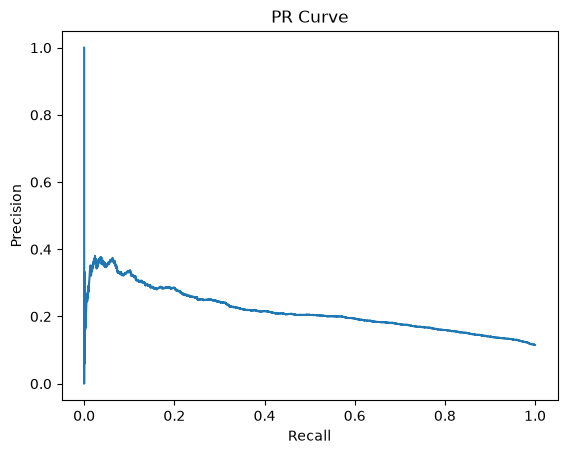

In [ ]:

plt.plot(rec, prec)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("PR Curve")

**Interpretación.** La curva está muy lejos de la esquina superior derecha. A diferencia del ejemplo del spam (precisión > 90 % hasta un 80 % de recall), aquí la precisión parte de ≈ 0,12 (la tasa base de impago) cuando el recall es 1 y solo sube a ≈ 0,20–0,25 cuando el recall baja al 30–50 %. Es decir, para detectar más impagos hay que aceptar muchos falsos positivos: el modelo **discrimina, pero de forma moderada**.

### Curva ROC
- **tpr** (sensibilidad): % de impagos reales detectados.
- **fpr** (1 − especificidad): % de clientes que pagan clasificados erróneamente como impago.
- **threshold**: umbral que genera cada pareja (tpr, fpr).

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, predicciones)
pd.DataFrame({"tpr":tpr, "fpr":fpr, "threshold":threshold})


,tpr,fpr,threshold
0,0.000000,0.000000,inf
1,0.000000,0.000073,0.548955
2,0.000000,0.000147,0.536615
3,0.000563,0.000147,0.533421
4,0.000563,0.001176,0.439505
...,...,...,...
3040,0.998875,0.997208,0.015730
3041,0.999437,0.997208,0.015685
3042,0.999437,0.998530,0.014811
3043,1.000000,0.998530,0.014782


Text(0.5, 1.0, 'Curva ROC')

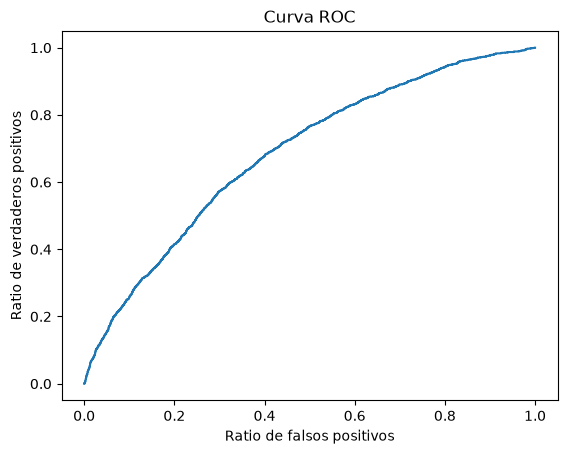

In [ ]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)

plt.xlabel("Ratio de falsos positivos")
plt.ylabel("Ratio de verdaderos positivos")
plt.title("Curva ROC")

**Interpretación.** La curva queda **por encima de la diagonal** (que sería un modelo aleatorio), pero no muy pegada a la esquina superior izquierda. La cuantificamos con el AUC en la siguiente sección.